# 🍼 Sobrevida Neonatal por Prematuridade — Brasil 2022

> **Fonte de dados:** SIM (Sistema de Informações sobre Mortalidade) × SINASC (Sistema de Informações sobre Nascidos Vivos) — MS/DATASUS, 2022  
> **Metodologia:** Probabilidade acumulada de óbito infantil (< 1 ano) por grupo de prematuridade, calculada em janelas temporais desde o nascimento.  
> **Contexto:** Análise desenvolvida no âmbito do TCC sobre acompanhamento pós-alta de recém-nascidos prematuros pelo Método Canguru — UFAL / Alagoas.

---

## Grupos gestacionais analisados

| Grupo | Semanas de gestação | Código SINASC |
|---|---|---|
| Extremamente prematuro | < 28 semanas | 1 ou 2 |
| Muito prematuro | 28 – 31 semanas | 3 |
| Prematuro tardio | 32 – 36 semanas | 4 |
| A termo | 37 – 41 semanas | 5 |

## Janelas de sobrevida

As probabilidades são calculadas de forma **acumulada** desde o nascimento:  
`até 24h → até 1 semana → até 1 mês → até 3 meses → até 6 meses`

---

## 1. Configuração e importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
from pysus import sim, sinasc

warnings.filterwarnings('ignore')

ANO = 2022

# Pastas de saída
PASTA_AL     = '../graficos/AL'
PASTA_OUTROS = '../graficos/outros_estados'
os.makedirs(PASTA_AL,     exist_ok=True)
os.makedirs(PASTA_OUTROS, exist_ok=True)

# ── Paleta visual ──────────────────────────────
TEAL   = '#0d9488'
SLATE  = '#334155'
RED    = '#e11d48'
AMBER  = '#f59e0b'
GRAY   = '#94a3b8'
LIGHT  = '#f1f5f9'
PURPLE = '#7c3aed'

GRUPOS_ORDEM = [
    'Extremamente\nprematuro\n(<28 sem)',
    'Muito\nprematuro\n(28–31 sem)',
    'Prematuro\ntardio\n(32–36 sem)',
    'A termo\n(37–41 sem)',
]

COR_GRUPO = {
    'Extremamente\nprematuro\n(<28 sem)': RED,
    'Muito\nprematuro\n(28–31 sem)':      AMBER,
    'Prematuro\ntardio\n(32–36 sem)':     PURPLE,
    'A termo\n(37–41 sem)':               TEAL,
}

JANELAS = {
    'Até\n24h':      1,
    'Até\n1 semana': 7,
    'Até\n1 mês':    28,
    'Até\n3 meses':  90,
    'Até\n6 meses':  180,
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LIGHT,
    'axes.edgecolor':   SLATE,
    'axes.labelcolor':  SLATE,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  SLATE,
    'xtick.color':      SLATE,
    'ytick.color':      SLATE,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
    'font.family':      'sans-serif',
    'text.color':       SLATE,
})

print('✅ Configuração carregada.')

✅ Configuração carregada.


## 2. Funções auxiliares

In [3]:
def classifica_grupo(gest):
    if pd.isna(gest):
        return None
    try:
        gest = int(gest)
    except:
        return None
    if gest in [1, 2]: return 'Extremamente\nprematuro\n(<28 sem)'
    if gest == 3:       return 'Muito\nprematuro\n(28–31 sem)'
    if gest == 4:       return 'Prematuro\ntardio\n(32–36 sem)'
    if gest == 5:       return 'A termo\n(37–41 sem)'
    return None


def prep_sim(df_raw):
    df = df_raw.copy()
    df['DTOBITO']   = pd.to_datetime(df['DTOBITO'], format='%d%m%Y', errors='coerce')
    df['DTNASC']    = pd.to_datetime(df['DTNASC'],  format='%d%m%Y', errors='coerce')
    df['IDADE_DIAS'] = (df['DTOBITO'] - df['DTNASC']).dt.days
    if 'TIPOBITO' in df.columns:
        df = df[df['TIPOBITO'] == '2']
    df = df[df['IDADE_DIAS'].between(0, 364)].copy()
    df['GESTACAO_N'] = pd.to_numeric(df['GESTACAO'], errors='coerce')
    df['GRUPO']      = df['GESTACAO_N'].apply(classifica_grupo)
    return df


def prep_sinasc(df_raw):
    df  = df_raw.copy()
    col = None
    for candidato in ['GESTACAO', 'SEMAGESTAC', 'GRAVIDEZ']:
        if candidato in df.columns:
            col = candidato
            break
    if col is None:
        return None, None
    df['GESTACAO_N'] = pd.to_numeric(df[col], errors='coerce')
    if col == 'SEMAGESTAC':
        def sem_para_faixa(s):
            if pd.isna(s): return None
            s = int(s)
            if s < 22: return 1
            if s < 28: return 2
            if s < 32: return 3
            if s < 37: return 4
            if s < 42: return 5
            return 6
        df['GESTACAO_N'] = df['GESTACAO_N'].apply(sem_para_faixa)
    df['GRUPO'] = df['GESTACAO_N'].apply(classifica_grupo)
    return df, col


def calcula_probabilidades(df_inf, denominadores):
    resultados = {}
    df_clean   = df_inf[df_inf['GRUPO'].notna()].copy()
    for grupo in GRUPOS_ORDEM:
        resultados[grupo] = {}
        n_nascidos = denominadores.get(grupo, 0)
        df_grupo   = df_clean[df_clean['GRUPO'] == grupo]
        for janela_label, limite_dias in JANELAS.items():
            n_mortos = (df_grupo['IDADE_DIAS'] < limite_dias).sum()
            prob     = (n_mortos / n_nascidos * 100) if n_nascidos > 0 else 0
            resultados[grupo][janela_label] = round(prob, 2)
    return resultados


def gera_grafico(uf, resultados, denominadores, ano, pasta, mostrar=False):
    janelas_labels = list(JANELAS.keys())
    n_janelas = len(janelas_labels)
    n_grupos  = len(GRUPOS_ORDEM)
    width     = 0.18
    x         = np.arange(n_janelas)

    fig, ax = plt.subplots(figsize=(14, 7))

    for i, grupo in enumerate(GRUPOS_ORDEM):
        valores  = [resultados[grupo][j] for j in janelas_labels]
        posicoes = x + (i - n_grupos / 2 + 0.5) * width
        cor      = COR_GRUPO[grupo]
        bars     = ax.bar(posicoes, valores, width=width * 0.92,
                          color=cor, zorder=2, alpha=0.92)
        for bar, val in zip(bars, valores):
            if val >= 0.05:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f'{val:.1f}%',
                    ha='center', va='bottom',
                    fontsize=7.5, color=SLATE, fontweight='bold'
                )

    ax.set_xticks(x)
    ax.set_xticklabels(janelas_labels, fontsize=11)
    ax.set_ylabel('Probabilidade acumulada de óbito (%)', fontsize=11)
    ax.set_xlabel('Janela de sobrevida (acumulado desde o nascimento)', fontsize=10)
    ax.set_title(
        f'Probabilidade Acumulada de Óbito Infantil por Grupo de Prematuridade\n'
        f'{uf} — {ano}  |  Fonte: SIM × SINASC / MS-DATASUS',
        fontsize=13, pad=15
    )
    ax.yaxis.grid(True, zorder=1, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    ylim_max = max(
        max(resultados[g][j] for j in janelas_labels)
        for g in GRUPOS_ORDEM
    )
    ax.set_ylim(0, max(ylim_max * 1.2, 1))

    handles = []
    for grupo in GRUPOS_ORDEM:
        n         = denominadores.get(grupo, 0)
        nome_curto = grupo.replace('\n', ' ')
        handles.append(mpatches.Patch(
            color=COR_GRUPO[grupo],
            label=f'{nome_curto}  (n={n:,} nascidos)'
        ))
    ax.legend(handles=handles, loc='upper left',
              framealpha=0.95, fontsize=9.5,
              title='Grupo gestacional', title_fontsize=10)

    fig.text(
        0.99, 0.01,
        'Nota: excluídos óbitos com gestação ignorada ou pós-termo (≥42 sem).\n'
        'Denominador = nascidos vivos (SINASC). Numerador = óbitos infantis (SIM).',
        ha='right', va='bottom', fontsize=7.5, color=GRAY, style='italic'
    )

    plt.tight_layout()
    nome_arquivo = os.path.join(pasta, f'{uf}_sobrevida_neonatal_{ano}.png')
    plt.savefig(nome_arquivo, dpi=150, bbox_inches='tight')
    if mostrar:
        plt.show()
    else:
        plt.close()
    return nome_arquivo


print('✅ Funções carregadas.')

✅ Funções carregadas.


---

## 3. Análise — Alagoas (AL)

Alagoas é o estado de interesse primário desta análise, por ser o contexto de aplicação do Método Canguru estudado no TCC.  
O gráfico é exibido diretamente neste notebook e também salvo em `graficos/AL/`.

In [4]:
UF = 'AL'

print(f'⬇️  Baixando SIM {ANO} — {UF}...')
df_sim_raw  = sim(state=UF,  year=ANO)

print(f'⬇️  Baixando SINASC {ANO} — {UF}...')
df_nasc_raw = sinasc(state=UF, year=ANO)

print(f'\n📋 SIM  : {len(df_sim_raw):,} registros')
print(f'📋 SINASC: {len(df_nasc_raw):,} registros')

⬇️  Baixando SIM 2022 — AL...


⬇️  Baixando SINASC 2022 — AL...



📋 SIM  : 23,122 registros
📋 SINASC: 45,742 registros


In [5]:
df_inf           = prep_sim(df_sim_raw)
df_nasc, col_g   = prep_sinasc(df_nasc_raw)
denominadores_AL = df_nasc['GRUPO'].value_counts()
resultados_AL    = calcula_probabilidades(df_inf, denominadores_AL)

print(f'Óbitos infantis filtrados : {len(df_inf):,}')
print(f'Coluna de gestação usada  : {col_g}')
print('\nNascidos vivos por grupo:')
for grupo, n in denominadores_AL.items():
    print(f'  {grupo.replace(chr(10), " "):45s} → {n:,}')

Óbitos infantis filtrados : 580
Coluna de gestação usada  : GESTACAO

Nascidos vivos por grupo:
  A termo (37–41 sem)                           → 38,605
  Prematuro tardio (32–36 sem)                  → 4,700
  Muito prematuro (28–31 sem)                   → 466
  Extremamente prematuro (<28 sem)              → 245


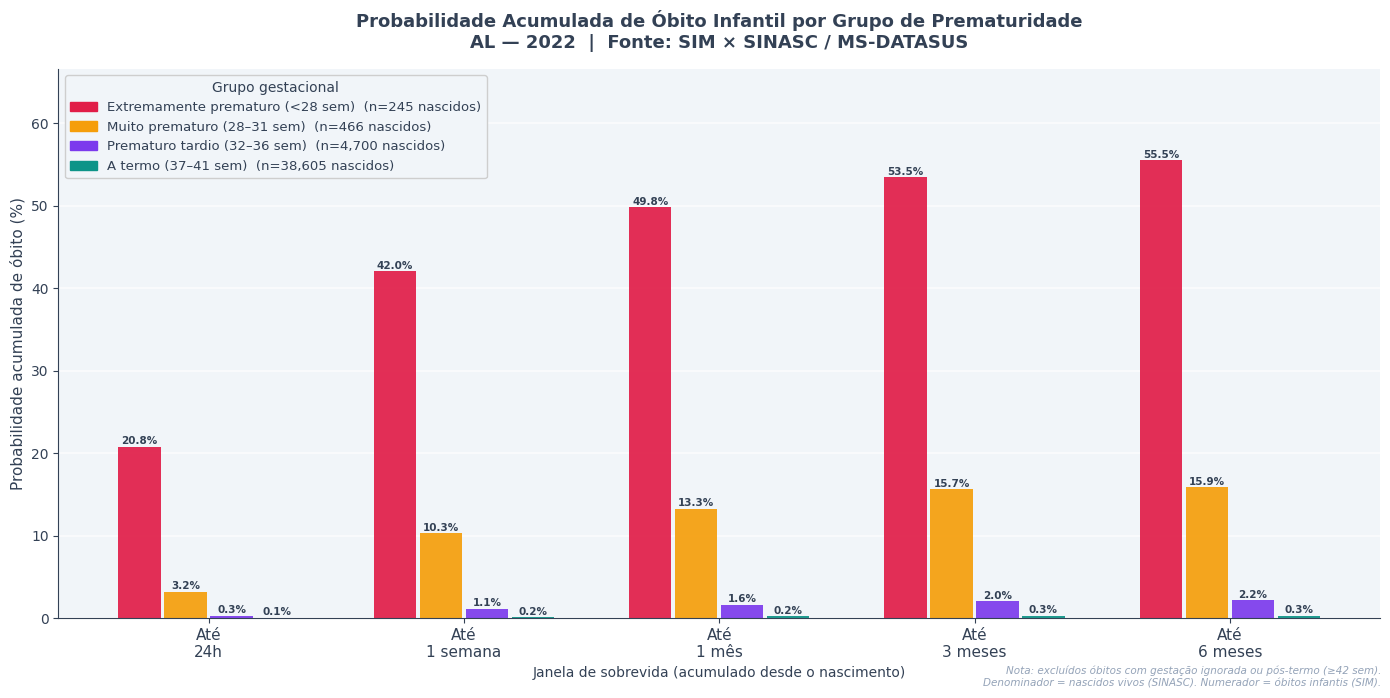


💾 Salvo em: ../graficos/AL/AL_sobrevida_neonatal_2022.png


In [6]:
# Exibe o gráfico inline E salva em graficos/AL/
caminho_AL = gera_grafico(UF, resultados_AL, denominadores_AL, ANO,
                          pasta=PASTA_AL, mostrar=True)
print(f'\n💾 Salvo em: {caminho_AL}')

---

## 4. Tabela de resultados — AL

Probabilidades acumuladas de óbito (%) por grupo e janela temporal.

In [7]:
rows = []
for grupo in GRUPOS_ORDEM:
    row = {'Grupo': grupo.replace('\n', ' ')}
    for janela in JANELAS:
        row[janela.replace('\n', ' ')] = f"{resultados_AL[grupo][janela]:.2f}%"
    rows.append(row)

df_tabela = pd.DataFrame(rows).set_index('Grupo')
df_tabela

,Até 24h,Até 1 semana,Até 1 mês,Até 3 meses,Até 6 meses
Grupo,,,,,
Extremamente prematuro (<28 sem),20.82%,42.04%,49.80%,53.47%,55.51%
Muito prematuro (28–31 sem),3.22%,10.30%,13.30%,15.67%,15.88%
Prematuro tardio (32–36 sem),0.34%,1.15%,1.64%,2.04%,2.23%
A termo (37–41 sem),0.05%,0.16%,0.24%,0.30%,0.34%


---

## 5. Geração para todos os estados

A célula abaixo gera e salva os gráficos de **todos os estados** em `graficos/outros_estados/`.  
Os gráficos **não** são exibidos no notebook para evitar poluição visual — acesse a pasta para visualizá-los.

> ⚠️ Esta célula faz download de dados de 26 UFs via pysus e pode demorar alguns minutos.

In [8]:
TODOS_ESTADOS = [
    'AC','AM','AP','BA','CE','DF','ES','GO',
    'MA','MG','MS','MT','PA','PB','PE','PI','PR',
    'RJ','RN','RO','RR','RS','SC','SE','SP','TO'
]  # AL já foi feito acima

erros   = []
sucesso = []

for uf in TODOS_ESTADOS:
    print(f'Processando {uf}...', end=' ')
    try:
        df_s = sim(state=uf,    year=ANO)
        df_n = sinasc(state=uf, year=ANO)

        if df_s is None or len(df_s) == 0 or df_n is None or len(df_n) == 0:
            print('⚠️  dados vazios')
            erros.append((uf, 'dados vazios'))
            continue

        df_i       = prep_sim(df_s)
        df_nc, _   = prep_sinasc(df_n)
        if df_nc is None:
            print('⚠️  coluna gestação não encontrada')
            erros.append((uf, 'coluna gestação'))
            continue

        denom = df_nc['GRUPO'].value_counts()
        res   = calcula_probabilidades(df_i, denom)
        gera_grafico(uf, res, denom, ANO, pasta=PASTA_OUTROS, mostrar=False)
        print('✅')
        sucesso.append(uf)

    except Exception as e:
        print(f'❌  {e}')
        erros.append((uf, str(e)))

print(f'\n✅ Gerados: {len(sucesso)} estados')
if erros:
    print(f'⚠️  Com erro: {[(u, m) for u, m in erros]}')

Processando AC... 

✅
Processando AM... 

✅
Processando AP... 

✅
Processando BA... 

✅
Processando CE... 

...

✅
Processando SC... 

✅
Processando SE... 

✅
Processando SP... 

⚠️  dados vazios
Processando TO... 

✅

✅ Gerados: 22 estados
⚠️  Com erro: [('CE', 'dados vazios'), ('MG', 'dados vazios'), ('PE', 'dados vazios'), ('SP', 'dados vazios')]


---

## Referências

- **SIM** — Sistema de Informações sobre Mortalidade. Ministério da Saúde / DATASUS, 2022.  
- **SINASC** — Sistema de Informações sobre Nascidos Vivos. Ministério da Saúde / DATASUS, 2022.  
- **pysus** — Biblioteca Python para acesso aos dados do DATASUS. [github.com/AlertaDengue/PySUS](https://github.com/AlertaDengue/PySUS)

---

<sub>Análise produzida para fins acadêmicos — TCC / UFAL. Os dados são públicos e disponibilizados pelo Ministério da Saúde.</sub>